# SIT307 – Machine Learning

## Task 8.1D ~ Machine Learning Mini Project: Sydney Housing Price Prediction and Decision Support System

This project focuses on developing a machine learning-based system for predicting residential property sale prices across three different Sydney housing markets. The analysis uses properties from **Chippendale, Parramatta and Penrith**, which were selected to provide variation in location, accessibility, housing density and property characteristics.

The final modelling dataset contains **150 sold properties**, with **50 properties from each suburb**. The prediction target is `sale_price`, while the available information includes property type, bedrooms, bathrooms, parking, sale method, property area, geographic location, distance from the Sydney CBD and proximity to railway stations.

Additional real-estate agent description text has also been retained to support an advanced text-based modelling experiment. The project will explore the dataset, engineer appropriate features, compare multiple regression approaches using cross-validation, investigate major prediction errors and deploy the selected model through a simple web-based application.

## Required Libraries

These libraries will be used for data preparation, visualisation, feature engineering, model development, cross-validation and performance evaluation throughout the project.

In [1]:
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    GridSearchCV
)

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.feature_extraction.text import TfidfVectorizer

warnings.filterwarnings("ignore")

## Part 1 – Problem Definition and Data Collection

This section defines the housing price prediction problem and introduces the dataset collected for Chippendale, Parramatta and Penrith. The three suburbs were selected to represent different Sydney housing markets in terms of location, housing type and accessibility. The dataset will first be checked to confirm its size, suburb distribution and overall structure before discussing its quality and limitations.

### Dataset Loading and Initial Structure

The final modelling dataset is loaded below to confirm the number of properties, available features and distribution of observations across the three selected suburbs.

In [2]:
df = pd.read_csv("sydney_housing_model_dataset.csv")

print("Dataset shape:", df.shape)

print("Properties per suburb:")
print(df["suburb"].value_counts())

print("Columns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (150, 16)
Properties per suburb:
suburb
Chippendale    50
Parramatta     50
Penrith        50
Name: count, dtype: int64
Columns:
['property_id', 'address', 'sale_price', 'sale_date', 'suburb', 'property_type', 'bedrooms', 'bathrooms', 'parking', 'sale_method', 'advertised_area_m2', 'latitude', 'longitude', 'distance_to_cbd_km', 'distance_to_nearest_station_km', 'agent_description_text']


,property_id,address,sale_price,sale_date,suburb,property_type,bedrooms,bathrooms,parking,sale_method,advertised_area_m2,latitude,longitude,distance_to_cbd_km,distance_to_nearest_station_km,agent_description_text
0,CHIP001,604/81 O'Connor Street,1825000,2026-08-05,Chippendale,Apartment,2,2,1.0,Private Treaty,NaN,-33.886130,151.200554,1.529,0.449,NaN
1,CHIP002,W614/2 Chippendale Way,535000,2026-08-03,Chippendale,Apartment,1,1,0.0,Private Treaty,46.0,-33.884614,151.200292,1.381,0.453,Light-Filled Studio with Balcony in Central Pa...
2,CHIP003,4/11 Meagher Street,750000,2026-07-30,Chippendale,Apartment,1,1,0.0,Private Treaty,56.0,-33.887590,151.199555,1.713,0.514,Contemporary Tri Level Living in the Heart of ...
3,CHIP004,718/18 Park Lane,520000,2026-07-30,Chippendale,Apartment,1,1,0.0,Private Treaty,NaN,-33.885736,151.201148,1.469,0.384,NaN
4,CHIP005,1513/1 Chippendale Way,680000,2026-07-29,Chippendale,Apartment,1,1,0.0,Private Treaty,NaN,-33.884415,151.199649,1.385,0.514,Discover Elevated Luxury Living at Central Par...


### Data Quality and Missing Information

The dataset is checked for duplicate records and missing values to assess the completeness of the main variables and identify limitations that may need to be considered during preprocessing and modelling.

In [3]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate property IDs:", df["property_id"].duplicated().sum())

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing (%)": (df.isnull().mean() * 100).round(1)
})

display(missing_summary)

Duplicate rows: 0
Duplicate property IDs: 0


,Missing Values,Missing (%)
property_id,0,0.0
address,0,0.0
sale_price,0,0.0
sale_date,0,0.0
suburb,0,0.0
property_type,0,0.0
bedrooms,0,0.0
bathrooms,0,0.0
parking,1,0.7
sale_method,0,0.0


### Housing Market Characteristics by Suburb

The three selected suburbs are compared using sale price statistics and property-type distributions to examine whether they represent meaningfully different housing markets.

In [4]:
price_summary = df.groupby("suburb")["sale_price"].agg(
    Count="count",
    Mean="mean",
    Median="median",
    Minimum="min",
    Maximum="max"
).round(0)

property_type_summary = pd.crosstab(
    df["suburb"],
    df["property_type"]
)

display(price_summary)
display(property_type_summary)

,Count,Mean,Median,Minimum,Maximum
suburb,,,,,
Chippendale,50,1104640.0,915000.0,250000,2226000
Parramatta,50,834208.0,691500.0,399000,3425000
Penrith,50,703390.0,656000.0,420000,1350000


property_type,Apartment,Block of units,Duplex,House,Semi-detached,Studio,Townhouse
suburb,,,,,,,
Chippendale,40,0,0,7,0,3,0
Parramatta,40,1,0,4,1,0,4
Penrith,33,0,1,11,0,0,5


### Availability of Additional Property Information

The coverage of additional area, location and text-based information is compared across the three suburbs to assess whether missing data is evenly distributed or concentrated within particular markets.

In [5]:
additional_features = [
    "advertised_area_m2",
    "latitude",
    "longitude",
    "distance_to_cbd_km",
    "distance_to_nearest_station_km",
    "agent_description_text"
]

coverage_by_suburb = (
    df.groupby("suburb")[additional_features]
    .count()
)

display(coverage_by_suburb)

,advertised_area_m2,latitude,longitude,distance_to_cbd_km,distance_to_nearest_station_km,agent_description_text
suburb,,,,,,
Chippendale,27,39,39,39,39,13
Parramatta,21,21,21,21,21,10
Penrith,27,23,23,23,23,8


### Evaluation

The final dataset contains 150 sold properties, with an equal distribution of 50 properties across Chippendale, Parramatta and Penrith. No duplicate records or duplicate property IDs were identified, while the core variables including sale price, property type, bedrooms and bathrooms were complete. Chippendale recorded the highest median sale price at 915,000, compared with  691,500 in Parramatta and $656,000 in Penrith. The property-type distribution also highlights clear market differences, with Chippendale dominated by apartments, while Penrith contains a greater proportion of houses and townhouses.

The dataset also contains several limitations. Advertised area is missing for 50% of properties, while geographic features are unavailable for 44.7%. Agent description text is available for only 31 properties, with 13 in Chippendale, 10 in Parramatta and 8 in Penrith. This uneven availability may introduce bias when these additional features are used. Overall, the dataset provides a balanced and diverse basis for housing price analysis, although missing information will require careful handling during preprocessing and modelling.

## Part 2 – Data Understanding and Feature Engineering

This section develops a clearer understanding of the housing dataset before predictive modelling begins. The analysis examines the distribution of sale prices, differences between the three selected suburbs, changes in prices over time, relationships between property characteristics and sale price, and potential outliers. These findings are then used to identify the variables expected to have the strongest influence on housing prices and guide the feature engineering process.

### Sale Price Distribution and Suburb Comparison

Sale prices are examined across the complete dataset and separately for Chippendale, Parramatta and Penrith. This provides an understanding of the overall price distribution and the differences in typical property values across the three housing markets.

count    1.500000e+02
mean     8.807459e+05
std      4.813142e+05
min      2.500000e+05
25%      5.885000e+05
50%      7.125000e+05
75%      9.400000e+05
max      3.425000e+06
Name: sale_price, dtype: float64

,Mean,Median,Std_Dev,Minimum,Maximum
suburb,,,,,
Chippendale,1104640.0,915000.0,560517.0,250000,2226000
Parramatta,834208.0,691500.0,512084.0,399000,3425000
Penrith,703390.0,656000.0,206346.0,420000,1350000


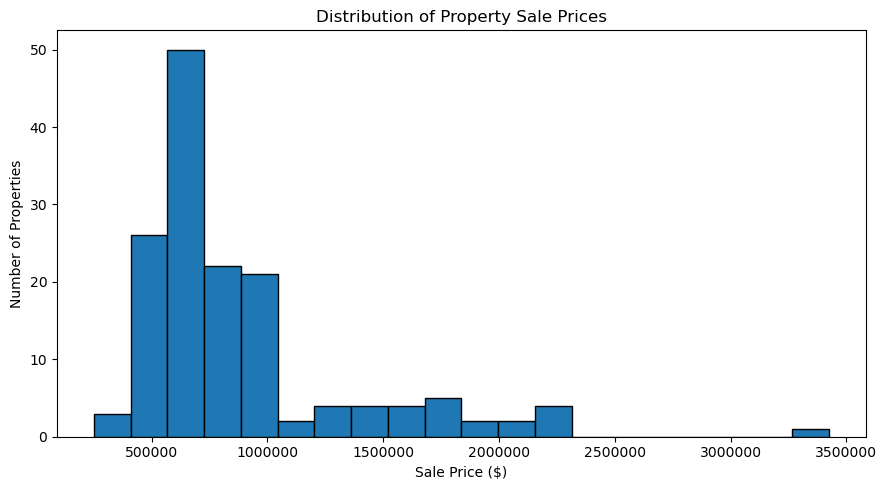

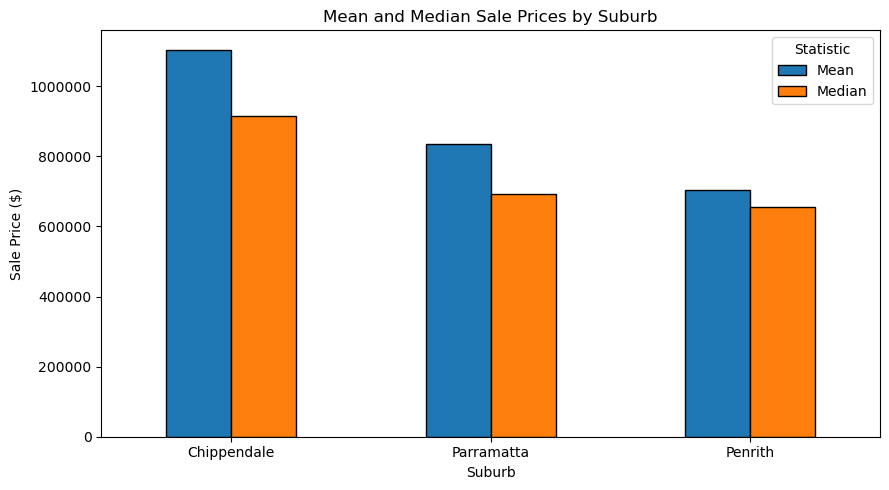

In [6]:
price_stats = df["sale_price"].describe()

suburb_price_stats = df.groupby("suburb")["sale_price"].agg(
    Mean="mean",
    Median="median",
    Std_Dev="std",
    Minimum="min",
    Maximum="max"
).round(0)

display(price_stats)
display(suburb_price_stats)

# Overall sale price distribution
plt.figure(figsize=(9, 5))
plt.hist(df["sale_price"], bins=20, edgecolor="black")
plt.title("Distribution of Property Sale Prices")
plt.xlabel("Sale Price ($)")
plt.ylabel("Number of Properties")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

# Mean and median sale prices by suburb
comparison = suburb_price_stats[["Mean", "Median"]]

comparison.plot(
    kind="bar",
    figsize=(9, 5),
    edgecolor="black"
)

plt.title("Mean and Median Sale Prices by Suburb")
plt.xlabel("Suburb")
plt.ylabel("Sale Price ($)")
plt.xticks(rotation=0)
plt.ticklabel_format(style="plain", axis="y")
plt.legend(title="Statistic")
plt.tight_layout()
plt.show()

### Sale Price Trends Over Time

Monthly median sale prices are compared across the three suburbs to examine how property values changed during the period covered by the dataset and whether the selected housing markets followed similar patterns.

,sale_date,suburb,sale_price
0,2025-10,Chippendale,865000.0
1,2025-11,Chippendale,950000.0
2,2026-01,Chippendale,840000.0
3,2026-01,Parramatta,720000.0
4,2026-01,Penrith,629500.0
5,2026-02,Chippendale,1494000.0
6,2026-02,Parramatta,728000.0
7,2026-02,Penrith,590000.0
8,2026-03,Chippendale,1740000.0
9,2026-03,Penrith,837500.0


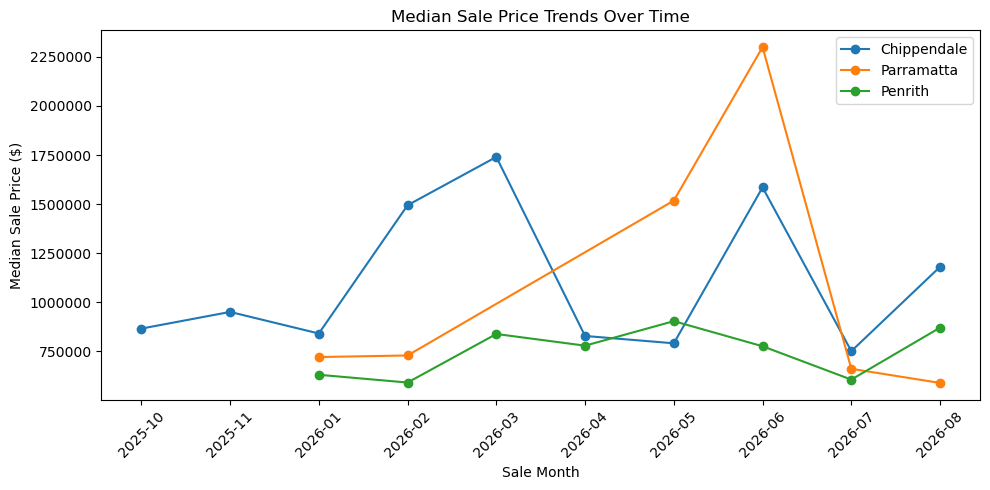

In [7]:
df["sale_date"] = pd.to_datetime(df["sale_date"])

monthly_prices = (
    df.groupby([df["sale_date"].dt.to_period("M"), "suburb"])["sale_price"]
    .median()
    .reset_index()
)

monthly_prices["sale_date"] = monthly_prices["sale_date"].astype(str)

display(monthly_prices)

plt.figure(figsize=(10, 5))

for suburb in monthly_prices["suburb"].unique():
    suburb_data = monthly_prices[monthly_prices["suburb"] == suburb]

    plt.plot(
        suburb_data["sale_date"],
        suburb_data["sale_price"],
        marker="o",
        label=suburb
    )

plt.title("Median Sale Price Trends Over Time")
plt.xlabel("Sale Month")
plt.ylabel("Median Sale Price ($)")
plt.xticks(rotation=45)
plt.ticklabel_format(style="plain", axis="y")
plt.legend()
plt.tight_layout()
plt.show()

### Feature Relationships, Property Characteristics and Potential Outliers

The relationships between sale price and the available numerical features are examined alongside categorical characteristics such as property type and sale method. Potential price outliers are also identified to determine whether unusual properties may influence the later modelling results.

Correlation with sale price:


,Correlation
bedrooms,0.621
longitude,0.387
bathrooms,0.360
parking,0.356
advertised_area_m2,0.210
distance_to_nearest_station_km,-0.040
distance_to_cbd_km,-0.385
latitude,-0.434


Sale price by property type:


,Count,Mean,Median
property_type,,,
Block of units,1,3425000.0,3425000.0
Semi-detached,1,1438888.0,1438888.0
House,22,1391250.0,1415000.0
Duplex,1,995000.0,995000.0
Townhouse,9,860056.0,851000.0
Apartment,113,767018.0,665000.0
Studio,3,410667.0,407000.0


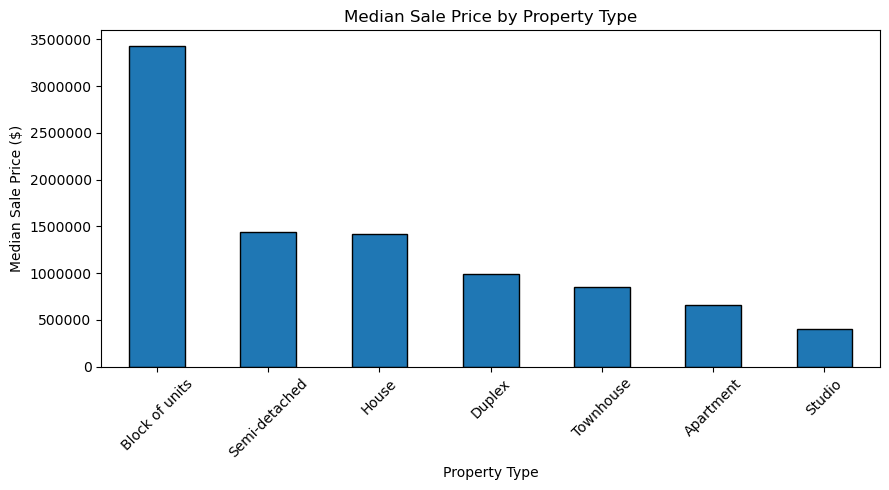

Sale price by sale method:


,Count,Mean,Median
sale_method,,,
Prior to Auction,8,1405938.0,1405000.0
Auction,20,1006669.0,871500.0
Private Treaty,122,825664.0,680000.0



Lower outlier boundary: $61,250
Upper outlier boundary: $1,467,250
Number of potential price outliers: 20


,property_id,address,suburb,property_type,sale_price,bedrooms,bathrooms,advertised_area_m2
71,PARR022,37A Sutherland Road,Parramatta,Block of units,3425000,12,6,903.0
74,PARR025,124 Thomas Street,Parramatta,House,2300000,3,1,739.0
22,CHIP023,5/3 Queen Street,Chippendale,Apartment,2226000,2,2,NaN
10,CHIP011,2602/18A Park Lane,Chippendale,Apartment,2165000,3,2,186.0
11,CHIP012,3/3 Queen Street,Chippendale,Apartment,2160000,2,2,NaN
7,CHIP008,26 Shepherd Street,Chippendale,House,2105000,3,2,108.0
34,CHIP035,70 Rose Street,Chippendale,House,2100000,3,1,139.0
33,CHIP034,2 Smithers Street,Chippendale,House,1937500,3,1,94.8
14,CHIP015,52 Myrtle Street,Chippendale,House,1850000,3,1,NaN
0,CHIP001,604/81 O'Connor Street,Chippendale,Apartment,1825000,2,2,NaN


In [8]:
# Numerical relationships with sale price
numeric_features = [
    "bedrooms",
    "bathrooms",
    "parking",
    "advertised_area_m2",
    "latitude",
    "longitude",
    "distance_to_cbd_km",
    "distance_to_nearest_station_km"
]

correlations = (
    df[numeric_features + ["sale_price"]]
    .corr(numeric_only=True)["sale_price"]
    .drop("sale_price")
    .sort_values(ascending=False)
    .round(3)
)

print("Correlation with sale price:")
display(correlations.to_frame("Correlation"))


# Property type comparison
property_type_stats = (
    df.groupby("property_type")["sale_price"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median"
    )
    .sort_values("Median", ascending=False)
    .round(0)
)

print("Sale price by property type:")
display(property_type_stats)

property_type_stats["Median"].plot(
    kind="bar",
    figsize=(9, 5),
    edgecolor="black"
)

plt.title("Median Sale Price by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Median Sale Price ($)")
plt.xticks(rotation=45)
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


# Sale method comparison
sale_method_stats = (
    df.groupby("sale_method")["sale_price"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median"
    )
    .sort_values("Median", ascending=False)
    .round(0)
)

print("Sale price by sale method:")
display(sale_method_stats)


# Detect potential price outliers using the IQR method
Q1 = df["sale_price"].quantile(0.25)
Q3 = df["sale_price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

price_outliers = df[
    (df["sale_price"] < lower_bound) |
    (df["sale_price"] > upper_bound)
][
    [
        "property_id",
        "address",
        "suburb",
        "property_type",
        "sale_price",
        "bedrooms",
        "bathrooms",
        "advertised_area_m2"
    ]
].sort_values("sale_price", ascending=False)

print(f"\nLower outlier boundary: ${lower_bound:,.0f}")
print(f"Upper outlier boundary: ${upper_bound:,.0f}")
print(f"Number of potential price outliers: {len(price_outliers)}")

display(price_outliers)

### Expected Key Predictors and Additional Feature Considerations

Before creating engineered features, **suburb, bedrooms and property type** are expected to have the strongest influence on sale price. Suburb captures broader differences in location and housing markets, bedrooms provide an indication of property capacity, and property type distinguishes between structurally different properties such as houses, apartments and townhouses.

Additional information could further improve predictive performance, particularly more complete internal floor-area measurements, property age, renovation condition and accessibility information. Real-estate agent descriptions are also available for a subset of properties and will be retained for a later text-based modelling experiment.

### Feature Engineering

A small set of additional features is created to represent transaction timing, overall property capacity and parking availability in a form that can be used more effectively during modelling.

In [9]:
model_df = df.copy()

# Represent each sale relative to the earliest transaction in the dataset
first_sale = model_df["sale_date"].min()

model_df["months_since_first_sale"] = (
    (model_df["sale_date"].dt.year - first_sale.year) * 12
    + (model_df["sale_date"].dt.month - first_sale.month)
)

# Combined measure of property capacity
model_df["total_rooms"] = (
    model_df["bedrooms"] + model_df["bathrooms"]
)

# Indicator for whether parking is available
model_df["has_parking"] = (
    model_df["parking"].fillna(0) > 0
).astype(int)

engineered_features = [
    "months_since_first_sale",
    "total_rooms",
    "has_parking"
]

print("Engineered features:")
print(engineered_features)

display(
    model_df[
        [
            "property_id",
            "sale_date",
            "bedrooms",
            "bathrooms",
            "parking",
            "months_since_first_sale",
            "total_rooms",
            "has_parking"
        ]
    ].head(10)
)

Engineered features:
['months_since_first_sale', 'total_rooms', 'has_parking']


,property_id,sale_date,bedrooms,bathrooms,parking,months_since_first_sale,total_rooms,has_parking
0,CHIP001,2026-08-05,2,2,1.0,10,4,1
1,CHIP002,2026-08-03,1,1,0.0,10,2,0
2,CHIP003,2026-07-30,1,1,0.0,9,2,0
3,CHIP004,2026-07-30,1,1,0.0,9,2,0
4,CHIP005,2026-07-29,1,1,0.0,9,2,0
5,CHIP006,2026-07-27,1,1,1.0,9,2,1
6,CHIP007,2026-07-21,2,1,1.0,9,3,1
7,CHIP008,2026-07-17,3,2,1.0,9,5,1
8,CHIP009,2026-07-14,1,1,1.0,9,2,1
9,CHIP010,2026-06-26,2,2,1.0,8,4,1


### Evaluation

The exploratory analysis identified clear differences across the three housing markets. Chippendale recorded the highest median sale price at 915,000, compared with 691,500 in Parramatta and $656,000 in Penrith. The overall price distribution was positively skewed, with several high-value properties extending beyond the main concentration of sales. Monthly median prices also fluctuated over the observed period, particularly in Chippendale and Parramatta, while Penrith showed comparatively more stable movements.

Among the numerical variables, bedrooms showed the strongest positive relationship with sale price, with a correlation of 0.621. Distance from the Sydney CBD showed a moderate negative correlation of -0.385, supporting the importance of location. Property type also produced noticeable differences, with houses recording a median price of approximately 1.415 million compared with 665,000 for apartments. The IQR method identified 20 potential price outliers, including a $3.425 million block of units in Parramatta.

The engineered features representing transaction timing, total rooms and parking availability were consistent with the initial expectation that location, property capacity and structural characteristics would influence housing value.

## Part 3 – Model Development and Evaluation

This section develops and compares three regression approaches for predicting property sale prices. Each model represents a different modelling strategy and will be evaluated using the same preprocessing process, five-fold cross-validation and regression metrics. Training and validation performance will also be compared to assess model complexity, underfitting and overfitting before selecting the most suitable model.

### Model Selection and Initial Expectation

Three regression models are considered: **Ridge Regression, Random Forest Regression and Support Vector Regression (SVR) with an RBF kernel**.

Ridge Regression provides a regularised linear baseline and is useful for determining how effectively the housing prices can be represented using relatively simple linear relationships. Random Forest can capture more complex non-linear relationships and interactions between features such as suburb, property type and property size, although it may overfit a relatively small dataset. SVR with an RBF kernel provides another non-linear approach and can model more flexible relationships, but its performance is sensitive to feature scaling and hyperparameter selection.

### Model Features and Preprocessing

The modelling features are separated into numerical and categorical groups. Missing numerical values are handled using median imputation, while categorical values are encoded using one-hot encoding. Numerical features are also standardised to ensure a fair comparison with scale-sensitive models such as Ridge Regression and SVR.

In [16]:
# Define the numerical and categorical predictors.
numeric_features = [
    "bedrooms",
    "bathrooms",
    "parking",
    "advertised_area_m2",
    "latitude",
    "longitude",
    "distance_to_cbd_km",
    "distance_to_nearest_station_km",
    "months_since_first_sale",
    "total_rooms",
    "has_parking"
]

categorical_features = [
    "suburb",
    "property_type",
    "sale_method"
]

# Separate predictors and target.
X = model_df[numeric_features + categorical_features]
y = model_df["sale_price"]

# Prepare numerical features.
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

# Prepare categorical features.
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both preprocessing steps.
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Number of properties:", X.shape[0])
print("Number of input variables:", X.shape[1])
print("Target variable: sale_price")

print("Numerical features:")
print(numeric_features)

print("Categorical features:")
print(categorical_features)

Number of properties: 150
Number of input variables: 14
Target variable: sale_price
Numerical features:
['bedrooms', 'bathrooms', 'parking', 'advertised_area_m2', 'latitude', 'longitude', 'distance_to_cbd_km', 'distance_to_nearest_station_km', 'months_since_first_sale', 'total_rooms', 'has_parking']
Categorical features:
['suburb', 'property_type', 'sale_method']


### Regression Model Pipelines

Three regression pipelines are created using the same preprocessing procedure. Ridge Regression represents a regularised linear approach, Random Forest represents a tree-based ensemble approach, and SVR with an RBF kernel represents a non-linear kernel-based approach. Using consistent preprocessing allows the models to be compared fairly during cross-validation.

In [19]:
# Ridge Regression with learning rate equivalent to 0.1
ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(
        alpha=1.0
    ))
])

# Random Forest using 500 trees; random_state keeps the results reproducible.
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=500,
        random_state=42
    ))
])

# RBF-SVR with C controlling penalty, gamma controlling kernel influence,
# and epsilon defining the tolerance around the regression line.
svr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVR(
        kernel="rbf",
        C=100,
        gamma="scale",
        epsilon=0.1
    ))
])

# Store all models for the same evaluation process.
models = {
    "Ridge Regression": ridge_model,
    "Random Forest": random_forest_model,
    "SVR (RBF)": svr_model
}

### Five-Fold Cross-Validation

The three regression models are evaluated using five-fold cross-validation with the same shuffled folds. MAE, RMSE and R² are used to compare prediction accuracy, sensitivity to larger errors and the proportion of variation in housing prices explained by each model. The variation in performance across folds is also reported to assess the stability of each approach.

In [20]:
# Use the same five folds for a fair model comparison.
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Evaluate each model using three regression metrics.
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_scores = {}
results = []

# Run five-fold cross-validation for each model.
for name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring
    )

    cv_scores[name] = scores

    results.append({
        "Model": name,
        "Mean MAE ($)": -scores["test_MAE"].mean(),
        "MAE Std ($)": scores["test_MAE"].std(),
        "Mean RMSE ($)": -scores["test_RMSE"].mean(),
        "RMSE Std ($)": scores["test_RMSE"].std(),
        "Mean R²": scores["test_R2"].mean(),
        "R² Std": scores["test_R2"].std()
    })

# Summarise the average performance across all five folds.
cv_results = pd.DataFrame(results)

cv_results[
    ["Mean MAE ($)", "MAE Std ($)", "Mean RMSE ($)", "RMSE Std ($)"]
] = cv_results[
    ["Mean MAE ($)", "MAE Std ($)", "Mean RMSE ($)", "RMSE Std ($)"]
].round(0)

cv_results[["Mean R²", "R² Std"]] = (
    cv_results[["Mean R²", "R² Std"]].round(3)
)

display(
    cv_results.sort_values("Mean MAE ($)").reset_index(drop=True)
)

,Model,Mean MAE ($),MAE Std ($),Mean RMSE ($),RMSE Std ($),Mean R²,R² Std
0,Random Forest,173540.0,27989.0,286915.0,100139.0,0.598,0.162
1,Ridge Regression,198499.0,24253.0,281807.0,52532.0,0.600,0.125
2,SVR (RBF),304644.0,60699.0,494754.0,117430.0,-0.141,0.090


### Cross-Validation Performance Comparison

The individual fold results are reviewed to assess the consistency of each model across different subsets of the dataset. Mean MAE, RMSE and R² are then visualised using bar charts to provide a clear comparison of overall predictive performance.

,Model,Fold,MAE ($),RMSE ($),R²
0,Ridge Regression,1,177278.0,239107.0,0.649
1,Ridge Regression,2,238046.0,372044.0,0.519
2,Ridge Regression,3,214896.0,268292.0,0.680
3,Ridge Regression,4,186388.0,225612.0,0.399
4,Ridge Regression,5,175887.0,303978.0,0.750
5,Random Forest,1,137830.0,218186.0,0.708
6,Random Forest,2,209836.0,314785.0,0.656
7,Random Forest,3,162689.0,208193.0,0.807
8,Random Forest,4,154654.0,221622.0,0.420
9,Random Forest,5,202691.0,471790.0,0.399


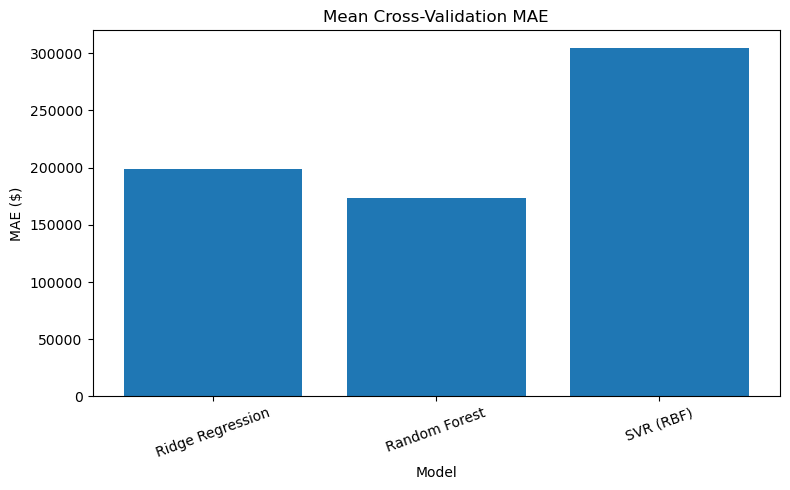

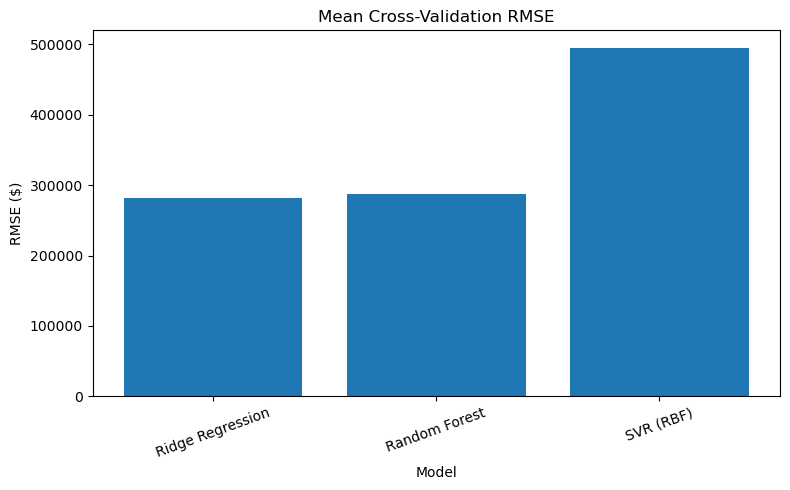

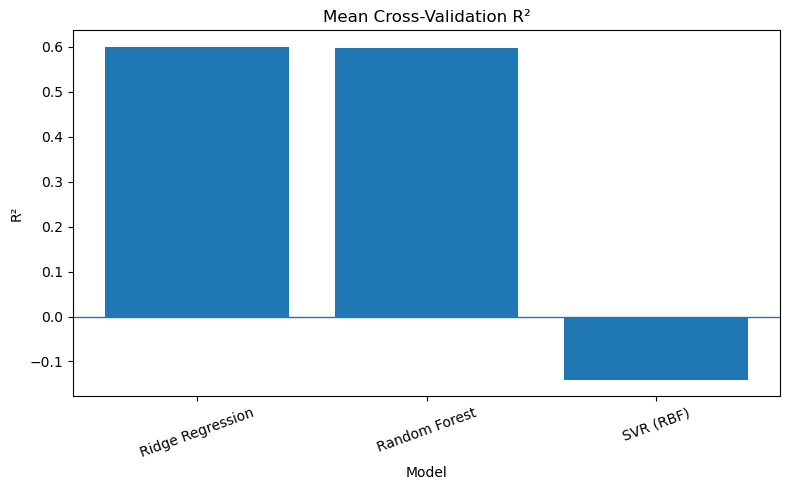

In [23]:
# Collect the results from each cross-validation fold.
fold_results = []

for model_name, scores in cv_scores.items():
    for fold in range(5):
        fold_results.append({
            "Model": model_name,
            "Fold": fold + 1,
            "MAE ($)": -scores["test_MAE"][fold],
            "RMSE ($)": -scores["test_RMSE"][fold],
            "R²": scores["test_R2"][fold]
        })

fold_results = pd.DataFrame(fold_results)

# Round the results for clearer presentation.
fold_results["MAE ($)"] = fold_results["MAE ($)"].round(0)
fold_results["RMSE ($)"] = fold_results["RMSE ($)"].round(0)
fold_results["R²"] = fold_results["R²"].round(3)

display(fold_results)


# Compare the average MAE of each model.
plt.figure(figsize=(8, 5))

plt.bar(
    cv_results["Model"],
    cv_results["Mean MAE ($)"]
)

plt.title("Mean Cross-Validation MAE")
plt.xlabel("Model")
plt.ylabel("MAE ($)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# Compare the average RMSE of each model.
plt.figure(figsize=(8, 5))

plt.bar(
    cv_results["Model"],
    cv_results["Mean RMSE ($)"]
)

plt.title("Mean Cross-Validation RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE ($)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# Compare the average R² of each model.
plt.figure(figsize=(8, 5))

plt.bar(
    cv_results["Model"],
    cv_results["Mean R²"]
)

plt.axhline(0, linewidth=1)
plt.title("Mean Cross-Validation R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Underfitting and Overfitting Analysis

Training and validation performance are compared across the same five cross-validation folds. A large difference between training and validation scores may indicate overfitting, while consistently weak performance on both sets may suggest that the model is underfitting the housing data.

In [24]:
# Compare training and validation performance using the same five folds.
generalisation_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=True
    )

    generalisation_results.append({
        "Model": name,

        "Train MAE ($)": -scores["train_MAE"].mean(),
        "Validation MAE ($)": -scores["test_MAE"].mean(),

        "Train RMSE ($)": -scores["train_RMSE"].mean(),
        "Validation RMSE ($)": -scores["test_RMSE"].mean(),

        "Train R²": scores["train_R2"].mean(),
        "Validation R²": scores["test_R2"].mean()
    })

generalisation_results = pd.DataFrame(generalisation_results)

# Round the values for clearer comparison.
generalisation_results[
    [
        "Train MAE ($)",
        "Validation MAE ($)",
        "Train RMSE ($)",
        "Validation RMSE ($)"
    ]
] = generalisation_results[
    [
        "Train MAE ($)",
        "Validation MAE ($)",
        "Train RMSE ($)",
        "Validation RMSE ($)"
    ]
].round(0)

generalisation_results[
    ["Train R²", "Validation R²"]
] = generalisation_results[
    ["Train R²", "Validation R²"]
].round(3)

display(generalisation_results)

,Model,Train MAE ($),Validation MAE ($),Train RMSE ($),Validation RMSE ($),Train R²,Validation R²
0,Ridge Regression,156557.0,198499.0,221840.0,281807.0,0.784,0.600
1,Random Forest,60384.0,173540.0,99455.0,286915.0,0.957,0.598
2,SVR (RBF),303125.0,304644.0,507005.0,494754.0,-0.121,-0.141


### Random Forest Hyperparameter Tuning

Random Forest achieved the lowest validation MAE but showed a large gap between training and validation performance, indicating overfitting. Hyperparameter tuning is therefore used to control tree complexity and determine whether stronger generalisation can be achieved.

In [27]:
# Explore a range of Random Forest settings.
rf_param_grid = {
    "model__n_estimators": [200, 500, 800],
    "model__max_depth": [3, 5, 8, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5]
}

# Tune the model using five-fold cross-validation.
rf_grid_search = GridSearchCV(
    estimator=random_forest_model,
    param_grid=rf_param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1
)

# Train all parameter combinations.
rf_grid_search.fit(X, y)

# Extract the best MAE found during tuning.
best_mae = -rf_grid_search.best_score_

# Retrieve the baseline Random Forest MAE.
baseline_rf_mae = cv_results.loc[
    cv_results["Model"] == "Random Forest",
    "Mean MAE ($)"
].iloc[0]

# Calculate the percentage improvement after tuning.
improvement_percent = (
    (baseline_rf_mae - best_mae) / baseline_rf_mae
) * 100

print("Best Random Forest parameters:")
print(rf_grid_search.best_params_)

print(f"Baseline MAE: ${baseline_rf_mae:,.0f}")
print(f"Tuned MAE: ${best_mae:,.0f}")
print(f"Improvement: {improvement_percent:.2f}%")

Best Random Forest parameters:
{'model__max_depth': None, 'model__max_features': 0.5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 800}

Baseline MAE: $173,540
Tuned MAE: $165,260
Improvement: 4.77%


### Final Random Forest Comparison

The tuned Random Forest is compared with the original baseline model using the same five-fold cross-validation procedure. MAE, RMSE and R² are evaluated alongside training and validation performance to determine whether tuning improved prediction accuracy and generalisation.

In [28]:
# Use the best Random Forest configuration found during tuning.
tuned_rf_model = rf_grid_search.best_estimator_

comparison_models = {
    "Baseline Random Forest": random_forest_model,
    "Tuned Random Forest": tuned_rf_model
}

final_results = []

# Evaluate both versions using the same five folds.
for name, model in comparison_models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=True
    )

    final_results.append({
        "Model": name,
        "Validation MAE ($)": -scores["test_MAE"].mean(),
        "Validation RMSE ($)": -scores["test_RMSE"].mean(),
        "Validation R²": scores["test_R2"].mean(),
        "Train R²": scores["train_R2"].mean()
    })

final_comparison = pd.DataFrame(final_results)

# Round the results for clearer presentation.
final_comparison[
    ["Validation MAE ($)", "Validation RMSE ($)"]
] = final_comparison[
    ["Validation MAE ($)", "Validation RMSE ($)"]
].round(0)

final_comparison[
    ["Validation R²", "Train R²"]
] = final_comparison[
    ["Validation R²", "Train R²"]
].round(3)

display(final_comparison)

,Model,Validation MAE ($),Validation RMSE ($),Validation R²,Train R²
0,Baseline Random Forest,173540.0,286915.0,0.598,0.957
1,Tuned Random Forest,165260.0,278810.0,0.621,0.959


### Evaluation

The three regression approaches produced clearly different levels of predictive performance. Random Forest achieved the lowest baseline validation MAE at 173,540, while Ridge Regression produced a slightly lower RMSE of 281,807 and a similar R² of 0.600. SVR performed considerably worse, recording an MAE of $304,644 and a negative R² of -0.141, indicating that the selected baseline configuration was unable to model the housing-price relationships effectively.

Training and validation results also highlighted differences in model complexity. Ridge showed a moderate performance gap, with training and validation R² values of 0.784 and 0.600. Random Forest showed stronger evidence of overfitting, with training R² of 0.957 compared with validation R² of 0.598. Hyperparameter tuning improved the Random Forest validation MAE to 165,260, RMSE to 278,810 and R² to 0.621, representing a 4.77% reduction in MAE. However, its training R² remained high at 0.959, indicating that some overfitting remains.

The initial expectation that Random Forest would perform best was therefore supported after tuning. The tuned Random Forest is recommended because it achieved the strongest overall validation performance, although its generalisation gap should be considered when interpreting predictions.

## Part 4 – Investigating Prediction Failures

This section investigates where the selected tuned Random Forest model produces its largest prediction errors. Out-of-fold predictions are first generated for all properties so that each prediction is produced while that property is excluded from the corresponding training fold. The resulting errors will then be used to identify and investigate the five most difficult properties.

### Out-of-Fold Predictions

Five-fold cross-validation is used to generate a prediction for every property. Prediction errors are calculated in both dollar and percentage terms to provide a consistent basis for identifying the largest model failures.

In [29]:
from sklearn.model_selection import cross_val_predict

# Generate a prediction for each property while it is held out from training.
oof_predictions = cross_val_predict(
    tuned_rf_model,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

# Store the predictions alongside the original property information.
prediction_errors = model_df.copy()

prediction_errors["predicted_price"] = oof_predictions
prediction_errors["prediction_error"] = (
    prediction_errors["sale_price"] - prediction_errors["predicted_price"]
)

prediction_errors["absolute_error"] = (
    prediction_errors["prediction_error"].abs()
)

prediction_errors["percentage_error"] = (
    prediction_errors["absolute_error"] /
    prediction_errors["sale_price"] * 100
)

# Summarise the out-of-fold prediction errors.
print("Properties evaluated:", len(prediction_errors))
print(
    "Overall out-of-fold MAE:",
    f'${prediction_errors["absolute_error"].mean():,.0f}'
)
print(
    "Largest absolute error:",
    f'${prediction_errors["absolute_error"].max():,.0f}'
)
print(
    "Median absolute error:",
    f'${prediction_errors["absolute_error"].median():,.0f}'
)

Properties evaluated: 150
Overall out-of-fold MAE: $165,260
Largest absolute error: $2,230,468
Median absolute error: $90,754


### Five Largest Prediction Errors

The five properties with the largest absolute prediction errors are identified for closer investigation. Their actual and predicted prices are compared alongside key property characteristics to determine whether unusual property types, size, location or missing information may have contributed to the model failures.

In [30]:
# Select the five properties with the largest prediction errors.
largest_errors = (
    prediction_errors
    .nlargest(5, "absolute_error")
    .copy()
)

# Show whether each property was underpredicted or overpredicted.
largest_errors["error_direction"] = np.where(
    largest_errors["prediction_error"] > 0,
    "Underpredicted",
    "Overpredicted"
)

# Prepare a clearer summary of the five properties.
failure_summary = largest_errors[
    [
        "property_id",
        "address",
        "suburb",
        "property_type",
        "sale_price",
        "predicted_price",
        "absolute_error",
        "percentage_error",
        "error_direction",
        "bedrooms",
        "bathrooms",
        "parking",
        "advertised_area_m2",
        "distance_to_cbd_km",
        "distance_to_nearest_station_km",
        "sale_method"
    ]
].copy()

# Round numerical values for presentation.
failure_summary["predicted_price"] = (
    failure_summary["predicted_price"].round(0)
)

failure_summary["absolute_error"] = (
    failure_summary["absolute_error"].round(0)
)

failure_summary["percentage_error"] = (
    failure_summary["percentage_error"].round(1)
)

display(failure_summary)

,property_id,address,suburb,property_type,sale_price,predicted_price,absolute_error,percentage_error,error_direction,bedrooms,bathrooms,parking,advertised_area_m2,distance_to_cbd_km,distance_to_nearest_station_km,sale_method
71,PARR022,37A Sutherland Road,Parramatta,Block of units,3425000,1194532.0,2230468.0,65.1,Underpredicted,12,6,6.0,903.0,NaN,NaN,Private Treaty
74,PARR025,124 Thomas Street,Parramatta,House,2300000,1279780.0,1020220.0,44.4,Underpredicted,3,1,1.0,739.0,NaN,NaN,Private Treaty
22,CHIP023,5/3 Queen Street,Chippendale,Apartment,2226000,1282304.0,943696.0,42.4,Underpredicted,2,2,1.0,NaN,1.625,0.504,Auction
11,CHIP012,3/3 Queen Street,Chippendale,Apartment,2160000,1312275.0,847725.0,39.2,Underpredicted,2,2,1.0,NaN,1.625,0.504,Private Treaty
38,CHIP039,11/9-27 Moorgate Street,Chippendale,Apartment,1600000,869263.0,730737.0,45.7,Underpredicted,2,1,1.0,NaN,NaN,NaN,Prior to Auction


### Contextual Investigation of Prediction Failures

The five largest prediction failures are compared with their broader suburb and property-type markets. Additional indicators are used to identify whether each property is unusually expensive, poorly represented by its property type, or affected by missing information that may have limited the model's ability to estimate its value accurately.

In [31]:
# Create contextual summaries from the complete dataset.
suburb_medians = model_df.groupby("suburb")["sale_price"].median()
type_medians = model_df.groupby("property_type")["sale_price"].median()
type_counts = model_df["property_type"].value_counts()

failure_context = largest_errors.copy()

# Compare each property with its local and structural market.
failure_context["suburb_median_price"] = (
    failure_context["suburb"].map(suburb_medians)
)

failure_context["property_type_median"] = (
    failure_context["property_type"].map(type_medians)
)

failure_context["property_type_count"] = (
    failure_context["property_type"].map(type_counts)
)

failure_context["above_suburb_median_pct"] = (
    (failure_context["sale_price"] - failure_context["suburb_median_price"])
    / failure_context["suburb_median_price"] * 100
)

# Record important missing information.
failure_context["missing_area"] = (
    failure_context["advertised_area_m2"].isna()
)

failure_context["missing_location"] = (
    failure_context[
        ["distance_to_cbd_km", "distance_to_nearest_station_km"]
    ].isna().any(axis=1)
)

failure_context["description_available"] = (
    failure_context["agent_description_text"].notna()
)

# Identify whether each case is also a high-price IQR outlier.
q1 = model_df["sale_price"].quantile(0.25)
q3 = model_df["sale_price"].quantile(0.75)
upper_bound = q3 + 1.5 * (q3 - q1)

failure_context["price_outlier"] = (
    failure_context["sale_price"] > upper_bound
)

context_summary = failure_context[
    [
        "property_id",
        "suburb",
        "property_type",
        "sale_price",
        "suburb_median_price",
        "above_suburb_median_pct",
        "property_type_count",
        "property_type_median",
        "missing_area",
        "missing_location",
        "description_available",
        "price_outlier"
    ]
].copy()

context_summary["above_suburb_median_pct"] = (
    context_summary["above_suburb_median_pct"].round(1)
)

display(context_summary)

,property_id,suburb,property_type,sale_price,suburb_median_price,above_suburb_median_pct,property_type_count,property_type_median,missing_area,missing_location,description_available,price_outlier
71,PARR022,Parramatta,Block of units,3425000,691500.0,395.3,1,3425000.0,False,True,False,True
74,PARR025,Parramatta,House,2300000,691500.0,232.6,22,1415000.0,False,True,False,True
22,CHIP023,Chippendale,Apartment,2226000,915000.0,143.3,113,665000.0,True,False,False,True
11,CHIP012,Chippendale,Apartment,2160000,915000.0,136.1,113,665000.0,True,False,True,True
38,CHIP039,Chippendale,Apartment,1600000,915000.0,74.9,113,665000.0,True,True,False,True


### Error Patterns Across Property Groups

Prediction errors are compared across suburbs, property types and missing-data groups to determine whether the largest failures represent isolated cases or broader weaknesses in the modelling approach. Property types with very small sample sizes are interpreted cautiously because their average errors may be influenced by only one or two properties.

In [32]:
# Compare prediction errors across suburbs.
suburb_error_summary = (
    prediction_errors.groupby("suburb")
    .agg(
        Properties=("property_id", "count"),
        Mean_Absolute_Error=("absolute_error", "mean"),
        Median_Absolute_Error=("absolute_error", "median")
    )
    .round(0)
    .sort_values("Mean_Absolute_Error", ascending=False)
)

print("Prediction error by suburb:")
display(suburb_error_summary)


# Compare errors across different property types.
property_type_error_summary = (
    prediction_errors.groupby("property_type")
    .agg(
        Properties=("property_id", "count"),
        Mean_Absolute_Error=("absolute_error", "mean"),
        Median_Absolute_Error=("absolute_error", "median")
    )
    .round(0)
    .sort_values("Mean_Absolute_Error", ascending=False)
)

print("\nPrediction error by property type:")
display(property_type_error_summary)


# Examine whether missing information is associated with larger errors.
prediction_errors["missing_area"] = (
    prediction_errors["advertised_area_m2"].isna()
)

prediction_errors["missing_location"] = (
    prediction_errors[
        ["distance_to_cbd_km", "distance_to_nearest_station_km"]
    ].isna().any(axis=1)
)

missing_data_summary = pd.DataFrame({
    "Group": [
        "Area available",
        "Area missing",
        "Location available",
        "Location missing"
    ],
    "Mean Absolute Error ($)": [
        prediction_errors.loc[
            ~prediction_errors["missing_area"], "absolute_error"
        ].mean(),

        prediction_errors.loc[
            prediction_errors["missing_area"], "absolute_error"
        ].mean(),

        prediction_errors.loc[
            ~prediction_errors["missing_location"], "absolute_error"
        ].mean(),

        prediction_errors.loc[
            prediction_errors["missing_location"], "absolute_error"
        ].mean()
    ]
})

missing_data_summary["Mean Absolute Error ($)"] = (
    missing_data_summary["Mean Absolute Error ($)"].round(0)
)

print("\nPrediction error and missing information:")
display(missing_data_summary)

Prediction error by suburb:


,Properties,Mean_Absolute_Error,Median_Absolute_Error
suburb,,,
Chippendale,50,240014.0,158455.0
Parramatta,50,151817.0,77499.0
Penrith,50,103948.0,68047.0



Prediction error by property type:


,Properties,Mean_Absolute_Error,Median_Absolute_Error
property_type,,,
Block of units,1,2230468.0,2230468.0
Studio,3,327230.0,399104.0
Semi-detached,1,269820.0,269820.0
House,22,268223.0,238638.0
Duplex,1,142561.0,142561.0
Apartment,113,127254.0,70173.0
Townhouse,9,98202.0,94550.0



Prediction error and missing information:


,Group,Mean Absolute Error ($)
0,Area available,194284.0
1,Area missing,136235.0
2,Location available,155907.0
3,Location missing,176845.0


### Evaluation

The largest prediction failures were concentrated among unusually expensive and poorly represented properties. All five of the largest errors were underpredictions and all five were identified as high-price outliers. The most extreme case was PARR022, a 3.425 million dollar block of units that was underpredicted by approximately $2.23 million. This property was especially difficult to model because it was the only block of units in the dataset and had highly unusual characteristics, including 12 bedrooms, 6 bathrooms and 903 m² of advertised area.

Other major failures involved premium houses and apartments whose prices were far above typical suburb and property-type values. Several of these properties also had missing advertised area or location information, which reduced the amount of context available to the model. In addition, characteristics such as renovation quality, views, floor level, building condition, land attributes and premium finishes were unavailable in the structured dataset.

Chippendale recorded the highest suburb-level mean absolute error at 240,014 dollara, indicating that predictions were less accurate in this market than in Parramatta and Penrith. When errors were examined by property type, houses recorded a mean absolute error of $268,223, which was higher than apartments and townhouses. Predictions should therefore be interpreted cautiously for expensive, unusual and less consistently represented properties.

## Part 5 – Housing Price Prediction Application

The final tuned Random Forest model is prepared for integration into a web-based decision-support application. The complete fitted pipeline is saved so that the same preprocessing and prediction process used during model evaluation can be applied consistently by the application backend.

In [34]:
# Use the best fitted model identified during hyperparameter tuning.
final_model = rf_grid_search.best_estimator_

# Save the complete preprocessing and prediction pipeline.
joblib.dump(
    final_model,
    "UI.joblib"
)


['UI.joblib']

### Model Export Verification

The saved machine learning pipeline is reloaded and tested using an existing property record. This verifies that the exported model retains the complete preprocessing and prediction pipeline required by the web application backend.

In [35]:
# Reload the exported prediction pipeline.
loaded_model = joblib.load("UI.joblib")

# Use one property to verify the saved model.
sample_property = X.iloc[[0]]

original_prediction = final_model.predict(sample_property)[0]
loaded_prediction = loaded_model.predict(sample_property)[0]

print(f"Original model prediction: ${original_prediction:,.0f}")
print(f"Loaded model prediction:   ${loaded_prediction:,.0f}")
print(f"Prediction difference:     ${abs(original_prediction - loaded_prediction):,.2f}")

Original model prediction: $1,762,791
Loaded model prediction:   $1,762,791
Prediction difference:     $0.00
